In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2020-06-18",
    end="2026-06-18"
)

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-06-18,85.138695,85.555033,84.531129,85.061235,96820400
2020-06-19,84.652153,86.307822,83.545951,85.843076,264476000
2020-06-22,86.867004,87.009817,84.998324,85.044315,135445200
2020-06-23,88.721153,90.137188,87.689988,88.108749,212155600
2020-06-24,87.155045,89.268205,86.782275,88.350807,192623200


In [23]:
data['Next_Close'] = data['Close'].shift(-1)
data = data.dropna()
features = ['Open', 'High', 'Low', 'Volume']
X = data[features]
y = data['Next_Close']
print(X.shape)
print(y.shape)

(1506, 4)
(1506,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=False)

In [53]:
LinearRegression_Model = LinearRegression()

LinearRegression_Model.fit(X_train, y_train)

print("Model Training Complete")

Model Training Complete


In [56]:
LinearRegression_pred = LinearRegression_Model.predict(X_test)

print("Predictions Generated")


Predictions Generated


In [57]:
mse = mean_squared_error(y_test, LinearRegression_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, LinearRegression_pred)
print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 4.650531885469006
R² Score: 0.9798723783422945


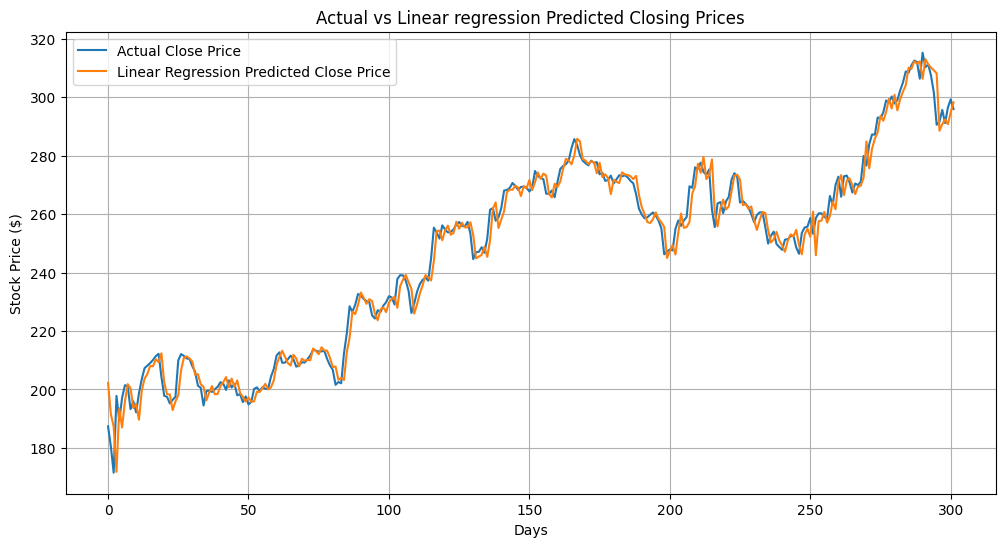

In [58]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Close Price"
)

plt.plot(
    LinearRegression_pred,
    label="Linear Regression Predicted Close Price"
)

plt.title("Actual vs Linear regression Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [59]:
latest_data = X.tail(1)

tomorrow_prediction = LinearRegression_Model.predict(latest_data)

print(
    "Linear Regression Predicted Next Day Closing Price:",
    round(float(tomorrow_prediction[0]), 2)
)

Linear Regression Predicted Next Day Closing Price: 298.21


In [60]:
from sklearn.ensemble import RandomForestRegressor

RandomForestRegressor_Model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

RandomForestRegressor_Model.fit(X_train, y_train)

RandomForestRegressor_pred = RandomForestRegressor_Model.predict(X_test)

mse = mean_squared_error(y_test,RandomForestRegressor_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, RandomForestRegressor_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 340.0346150959834
RMSE: 18.44002752427402
R² Score: 0.6835461836598293


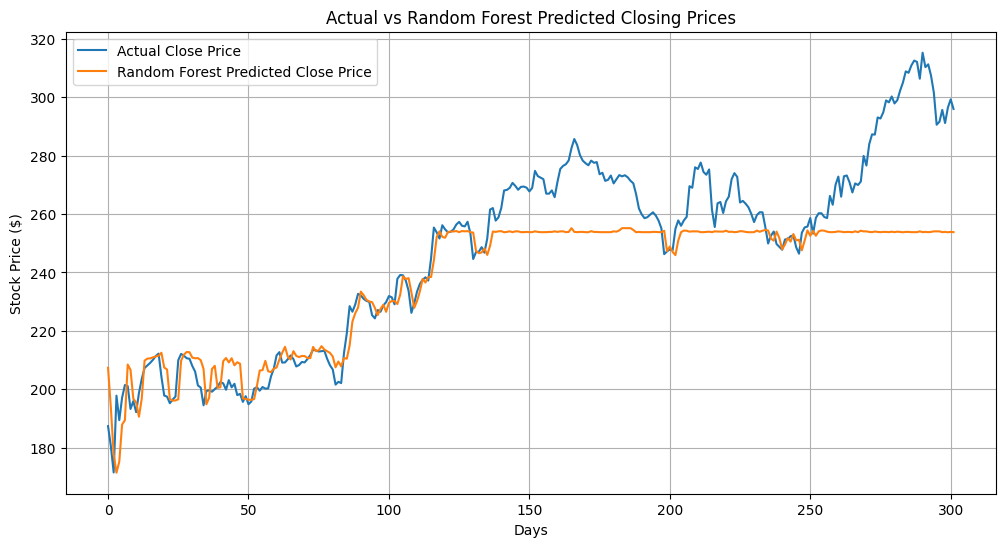

In [61]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Close Price"
)

plt.plot(
    RandomForestRegressor_pred,
    label="Random Forest Predicted Close Price"
)

plt.title("Actual vs Random Forest Predicted Closing Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [62]:
latest_data = X.tail(1)

tomorrow_prediction = RandomForestRegressor_Model.predict(latest_data)

print(
    "Random Forest Predicted Next Day Closing Price:",
    round(float(tomorrow_prediction[0]), 2)
)

Random Forest Predicted Next Day Closing Price: 253.78
